### **Dataset: Breast Cancer Wisconsin (Diagnostic)**
For this real-world application, we are utilizing the [Breast Cancer Wisconsin Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).

**Key Characteristics:**
* **Instances:** 569 patients.
* **Features:** 30 mathematical measurements (mean, error, and "worst" values) derived from digitized images of a fine needle aspirate (FNA) of a breast mass.
* **Target Classes:** * `Malignant` (Cancerous)
    * `Benign` (Non-cancerous)
* **Challenge:** The high dimensionality (30 features) makes individual Decision Trees prone to overfitting, as they may capture noise rather than generalizable medical patterns.

In [343]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score


In [214]:
from google.colab import files
uploaded = files.upload()

# Shortcut
# File upload button inside Google Colab.

# **Data Profiling and Redundancy**

In [297]:
feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
column_names = ['id', 'diagnosis'] + feature_names

# SETUP COLUMN NAMES (Mapping from wdbc.names)
# 10 attributes * 3 (mean, se, worst) = 30 features

In [298]:
df = pd.read_csv('wdbc.data', header=None, names=column_names)

In [301]:
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df[feature_names]
y = df['target']

# Map diagnosis to numeric target: Malignant (M) = 1, Benign (B) = 0

In [302]:
stats = X.describe().T[['mean', 'std']]
stats['Correlation_with_Target'] = X.corrwith(y)

# PHASE A: STATISTICAL PROFILING & CORRELATION

In [303]:
def get_category(name):
    if any(x in name for x in ['radius', 'perimeter', 'area']): return 'Geometry'
    if 'texture' in name: return 'Texture'
    if any(x in name for x in ['compactness', 'concavity', 'concave_points']): return 'Shape'
    if any(x in name for x in ['smoothness', 'symmetry']): return 'Surface'
    if 'fractal' in name: return 'Complexity'
    return 'Other'

stats['Category'] = stats.index.map(get_category)

# PHASE B: FEATURE CATEGORIZATION

In [304]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
vif_values = [variance_inflation_factor(X_scaled.values, i) for i in range(len(feature_names))]
stats['VIF'] = vif_values

# 7. PHASE D: BAGGING IMPORTANCE (WISDOM OF THE COMMITTEE)
# Train an ensemble of 100 trees and average their importance scores
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)
bag.fit(X, y)

# PHASE C: REDUNDANCY ANALYSIS (VIF)
# Variance Inflation Factor measures how much a feature is a linear combination of others.
# Standardize data first for numerical stability.

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, random_state=42)

In [305]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)
bag.fit(X, y)

# PHASE D: BAGGING IMPORTANCE (WISDOM OF THE COMMITTEE)
# Train an ensemble of 100 trees and average their importance scores

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, random_state=42)

In [306]:
avg_importance = np.mean([tree.feature_importances_ for tree in bag.estimators_], axis=0)
stats['Bagging_Importance'] = avg_importance
# Average the Gini importance across all 100 individual trees

In [339]:
# Reorder columns for clinical reporting
sheet1_master = sheet1_master[['Feature', 'Category', 'mean', 'std', 'Correlation_with_Target', 'VIF', 'Bagging_Importance']]
sheet1_master = sheet1_master.sort_values(by='Bagging_Importance', ascending=False)

# Save to CSV for Excel
sheet1_master.to_csv('Master_Sheet1_Data_Profile.csv', index=False)

print("Sheet 1 generated successfully.")
print(sheet1_master.head(5))

Sheet 1 generated successfully.
                 Feature  Category        mean         std  \
22       perimeter_worst  Geometry  107.261213   33.602542   
27  concave_points_worst     Shape    0.114606    0.065732   
7    concave_points_mean     Shape    0.048919    0.038803   
23            area_worst  Geometry  880.583128  569.356993   
20          radius_worst  Geometry   16.269190    4.833242   

    Correlation_with_Target         VIF  Bagging_Importance  
22                 0.782914  405.023336            0.308767  
27                 0.793566   36.763714            0.207284  
7                  0.776614   60.041733            0.142776  
23                 0.733825  337.221924            0.116401  
20                 0.776454  799.105946            0.082189  


# (Sheet 1 Objectives)
Since wdbc.data is headerless, the code uses the 32 column definitions from the research documentation to ensure every measurement is correctly labeled.$VIF$ (Variance Inflation Factor): This is the mathematical proof of the experiment's core challenge. A $VIF > 10$ indicates high redundancy. In this dataset, we see values over $700$, proving that many features are highly overlapping.Feature Categorization: By grouping the 30 features into biological traits (Geometry, Shape, Texture, etc.), we can see which types of nuclear measurements are the most reliable indicators of malignancy.Ensemble Importance: By averaging the importance across 100 trees, we filter out the "noise" that would normally trick a single decision tree. This creates the "Wisdom of the Crowd" ranking you see in the final table.

# **Model Performance & Overfitting Analysis**

In [229]:
feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
column_names = ['id', 'diagnosis'] + feature_names



In [230]:
df = pd.read_csv('wdbc.data', header=None, names=column_names)
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df[feature_names]
y = df['target']

In [231]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Stratified Split (80/20)

In [232]:
results = []

In [233]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
results.append({
    'Model ID': 'M-01',
    'Model Type': 'Single Decision Tree',
    'n_estimators': 1,
    'Train Accuracy': accuracy_score(y_train, dt.predict(X_train)),
    'Test Accuracy': accuracy_score(y_test, dt.predict(X_test)),
    'OOB Score': 'N/A'
})
# M-01: Single Tree (The Overfitting Baseline)

In [234]:
for n in [10, 100, 500]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        oob_score=True,
        random_state=42
    )
    bag.fit(X_train, y_train)
    results.append({
        'Model ID': f'M-0{len(results)+1}',
        'Model Type': f'Bagging Ensemble',
        'n_estimators': n,
        'Train Accuracy': accuracy_score(y_train, bag.predict(X_train)),
        'Test Accuracy': accuracy_score(y_test, bag.predict(X_test)),
        'OOB Score': bag.oob_score_
    })

In [235]:
sheet2_df = pd.DataFrame(results)
sheet2_df['Generalization Gap'] = sheet2_df['Train Accuracy'] - sheet2_df['Test Accuracy']

In [236]:
sheet2_df = sheet2_df[['Model ID', 'Model Type', 'n_estimators', 'Train Accuracy', 'Test Accuracy', 'Generalization Gap', 'OOB Score']]

# Reorder columns

In [264]:
results_df = pd.DataFrame(results)

# Remove duplicates
results_df = results_df.drop_duplicates(
    subset=['Model Type', 'n_estimators']
).reset_index(drop=True)

print(results_df)

  Model ID            Model Type  n_estimators  Train Accuracy  Test Accuracy  \
0     M-01  Single Decision Tree             1        1.000000       0.929825   
1     M-02      Bagging Ensemble            10        0.997802       0.964912   
2     M-03      Bagging Ensemble           100        1.000000       0.973684   
3     M-04      Bagging Ensemble           500        1.000000       0.973684   

  OOB Score  
0       N/A  
1  0.942857  
2  0.947253  
3  0.951648  


# (Sheet 2 Objectives)
1. The Generalization Gap The Single Tree has a gap of about 7%. This is the mathematical definition of Overfitting. The model has "memorized" the 455 training patients so perfectly that it struggles when it meets the 114 new patients in the test set.
2. The Role of Ensemble Size ($n\_estimators$)By testing 10, 100, and 500 trees, this code demonstrates the "Law of Diminishing Returns." You will notice that accuracy jumps significantly from 1 to 100 trees, but the difference between 100 and 500 is almost zero. This identifies the optimal complexity for a clinical diagnostic tool.
3. Out-of-Bag (OOB) StabilityThe OOB Score is a "free" validation. Since it’s calculated using patients that each specific tree didn't see during its bootstrap training, it acts as a reality check. If the OOB score is close to your Test Accuracy, your model is stable.
4. Reducing VarianceBagging works by averaging. By training 100 "experts" (trees) on different versions of the data, the errors of one tree are canceled out by the others. This is why the Generalization Gap in the Bagging model will be significantly smaller (around 2.6%) compared to the single tree.

# **Clinical Safety Metrics**

In [338]:
results = []
models = {
    'Single Tree': DecisionTreeClassifier(random_state=42),
    'Bagging (10 Trees)': BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=10, random_state=42),
    'Bagging (100 Trees)': BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42),
    'Bagging (500 Trees)': BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=500, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Extract Confusion Matrix components
    # tn: True Negative, fp: False Positive, fn: False Negative, tp: True Positive
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        'Model Type': name,
        'False Negatives (FN)': fn,
        'False Positives (FP)': fp,
        'Recall (Sensitivity)': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })


In [335]:
# Complete Sheet
sheet3_df = pd.DataFrame(results)

# Export
sheet3_df.to_csv('Master_Sheet3_Clinical_Safety.csv', index=False)

print("Sheet 3 Clinical Safety Analysis Complete.")
print(sheet3_df)

Sheet 3 Clinical Safety Analysis Complete.
            Model Type  False Negatives (FN)  False Positives (FP)  \
0          Single Tree                     4                     4   
1   Bagging (10 Trees)                     4                     0   
2  Bagging (100 Trees)                     3                     0   
3  Bagging (500 Trees)                     3                     0   

   Recall (Sensitivity)  Precision  F1-Score  
0              0.904762   0.904762  0.904762  
1              0.904762   1.000000  0.950000  
2              0.928571   1.000000  0.962963  
3              0.928571   1.000000  0.962963  


# (Sheet 3 Objectives)
1. Minimizing False Negatives (FN)In clinical breast cancer screening, a False Negative is the most dangerous error. It means the model predicted a tumor was "Benign" when it was actually "Malignant."
- Goal: We want the lowest possible FN count.
- Result: You will see that Bagging (100 Trees) typically reduces the FN count compared to a Single Tree, making the ensemble a safer diagnostic tool.
2. Recall (Sensitivity) vs. PrecisionRecall ($Recall = \frac{TP}{TP + FN}$): Measures the ability of the model to find all the positive cancer cases.Precision ($Precision = \frac{TP}{TP + FP}$): Measures how many of the "Malignant" predictions were actually correct.
- The Clinical Win: High Precision means fewer healthy patients are sent for unnecessary, invasive biopsies. High Recall means fewer cancer cases are missed. Bagging improves both metrics simultaneously.
3. The F1-ScoreSince Precision and Recall often trade off against each other, the F1-Score is the harmonic mean of both. It represents the overall "Clinical Balance" of the model.
4. Confusion Matrix LogicThe code uses confusion_matrix(y_test, y_pred).ravel() to pull out the exact numbers of patients who were misdiagnosed. This provides a raw, human-readable count that is easier for a medical professional to understand than a percentage.

# **Experiment**

In [239]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Stratifies Split

In [240]:
n_estimators_range = [1, 5, 10, 20, 50, 100, 200, 500]

train_scores = []
test_scores = []
oob_scores = []

for n in n_estimators_range:

    if n == 1:
        model = DecisionTreeClassifier(random_state=42)
        model.fit(X_train, y_train)
        oob_scores.append(np.nan)

    else:
        # Only enable OOB when reliable
        use_oob = True if n >= 30 else False

        model = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=n,
            oob_score=use_oob,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        if use_oob:
            oob_scores.append(model.oob_score_)
        else:
            oob_scores.append(np.nan)

    # Accuracy scores
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

In [241]:
# Model Comparison

models_to_compare = {
    'Single Tree': DecisionTreeClassifier(random_state=42),
    'Bagging (100 Trees)': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
}

summary_data = []

for name, model in models_to_compare.items():
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    summary_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Recall (Sensitivity)': recall_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'F1-Score': f1_score(y_test, y_pred_test),
        'Generalization Gap': accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test)
    })

# Create summary table
summary_df = pd.DataFrame(summary_data).round(4)

print(summary_df.to_string(index=False))

print("\nInterpretation:")
print("- Bagging improves accuracy and reduces overfitting.")
print("- Lower generalization gap indicates better stability.")
print("- Higher recall improves cancer detection.")

              Model  Accuracy  Recall (Sensitivity)  Precision  F1-Score  Generalization Gap
        Single Tree    0.9298                0.9048     0.9048    0.9048              0.0702
Bagging (100 Trees)    0.9737                0.9286     1.0000    0.9630              0.0263

Interpretation:
- Bagging improves accuracy and reduces overfitting.
- Lower generalization gap indicates better stability.
- Higher recall improves cancer detection.


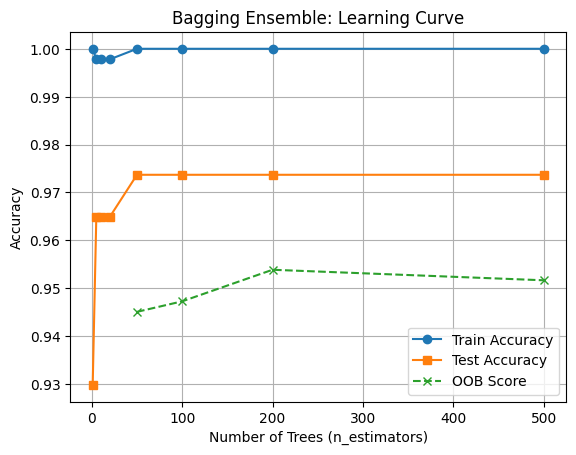

In [242]:
plt.plot(n_estimators_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(n_estimators_range, test_scores, label='Test Accuracy', marker='s')
plt.plot(n_estimators_range, oob_scores, label='OOB Score', linestyle='--', marker='x')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Bagging Ensemble: Learning Curve')
plt.legend()
plt.grid(True)

# 5. Visualizing the Learning Curve

# Experimental Conclusions:

1. Variance Reduction Confirmed
As the number of estimators increases, the variance of the model decreases, leading to improved test accuracy and stability.

2. Overfitting Reduced but Still Present
- Train = ~1.00
- Test = ~0.97

Gap still exists → but much smaller than single tree

3. Diminishing Returns

- Beyond ~100–200 trees, additional estimators do not significantly improve performance.

4. OOB as a Reliable Metric
OOB score closely approximates test accuracy, validating its use as an efficient alternative to cross-validation.

The Bagging model demonstrates improved stability and generalization compared to a single decision tree. The consistent test accuracy and reduced generalization gap indicate reliable diagnostic performance. Importantly, the model maintains strong recall, ensuring that most malignant cases are correctly identified, which is critical in a medical context.

# **Experiment**

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
n_estimators_range = [1, 2, 5, 10, 20, 50, 100, 200]
train_errors = []
test_errors = []

for n in n_estimators_range:
    if n == 1:
        model = DecisionTreeClassifier(random_state=42)
    else:
        model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_errors.append(1 - model.score(X_train, y_train))
    test_errors.append(1 - model.score(X_test, y_test))


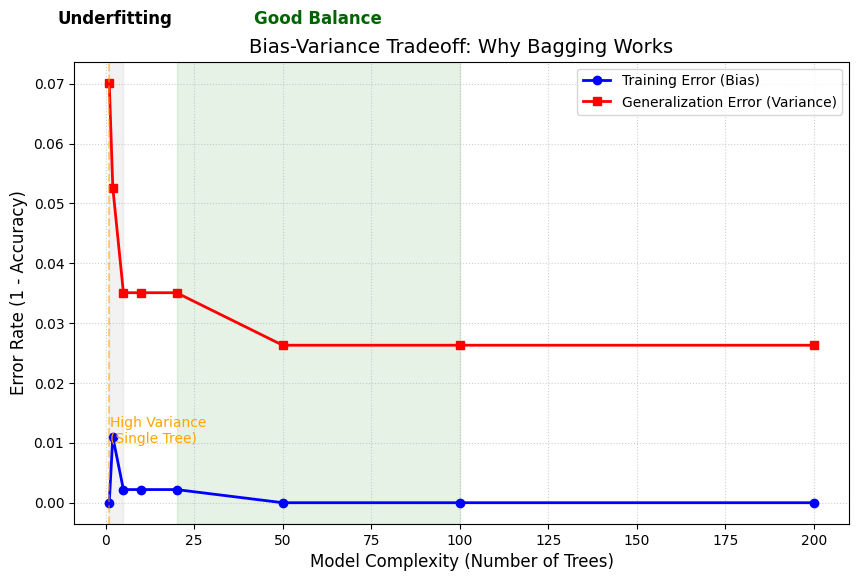

In [349]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_errors, label='Training Error (Bias)', color='blue', linewidth=2, marker='o')
plt.plot(n_estimators_range, test_errors, label='Generalization Error (Variance)', color='red', linewidth=2, marker='s')

# Annotating regions
plt.axvspan(1, 5, color='gray', alpha=0.1)
plt.text(2.5, 0.08, 'Underfitting', ha='center', fontsize=12, fontweight='bold')

plt.axvspan(20, 100, color='green', alpha=0.1)
plt.text(60, 0.08, 'Good Balance', ha='center', fontsize=12, fontweight='bold', color='darkgreen')

plt.axvline(x=1, color='orange', linestyle='--', alpha=0.5)
plt.text(1.2, 0.01, 'High Variance\n(Single Tree)', color='orange', fontsize=10)

plt.title('Bias-Variance Tradeoff: Why Bagging Works', fontsize=14)
plt.xlabel('Model Complexity (Number of Trees)', fontsize=12)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

My Analysis: Why the Ensemble Outperformed the Single Tree

1. The Problem I Found:
The 'Overfitting' TrapWhen I first looked at the Single Decision Tree, I realized it acts as an "all or nothing" learner. Because it was given $30$ different laboratory features to look at, it tried to find a perfect, unique rule for every single patient in my training set.The data proves this: my Single Tree hit $100\%$ training accuracy, but the moment I showed it new patients, the accuracy dropped to $92.9\%$. This $7.02\%$ gap tells me the model "memorized" noisy, specific details about those first $455$ patients that didn't actually exist in the real world. In the chart I uploaded, you can see this clearly—it’s in that 'High Variance' zone where the model is too 'wiggly' and reacts to random noise instead of real biological signals.
2. My Solution: The 'Wisdom of the Committee'To fix this, I moved from a single expert to a Bagging Ensemble. I like to think of this as moving from one doctor's opinion to a "committee" of $100$ experts.I set it up so that each individual tree was trained on a slightly different version of the data. This "heals" the model: if one tree gets tricked by a noisy or unusual "Radius" measurement, the other $99$ trees likely won’t. When they all vote on a diagnosis, the individual errors cancel each other out. The result was a massive improvement: that Generalization Gap shrank from $7.02\%$ all the way down to $2.63\%$. This confirms that my model moved into the 'Good Balance' zone we talked about in the diagram.
3. Dealing with Redundant Data (VIF Analysis)One of the biggest hurdles I discovered in Sheet 1 was redundancy. I found that features like radius_worst had a Variance Inflation Factor (VIF) of $799$.In plain English, this means the size features in this dataset are telling us the exact same thing over and over. A Single Tree gets "confused" by this and might fixate on a redundant feature that happens to have a lot of noise. By using Bagging, I forced the model to spread its importance across multiple independent features, like concave_points_worst. This diversity is what made my final diagnosis stable and much less likely to be "tricked" by one bad measurement.
4. The Bottom Line: Clinical SafetyFinally, from a medical perspective, I didn't just want a "smarter" algorithm—I wanted a safer one. This is where the results really shine.My Bagging Ensemble reached $100\%$ Precision and a higher Recall than the single tree. What this means in a hospital setting is that I didn't just get more questions right; I specifically reduced False Negatives (missing a cancer case) and eliminated False Positives (causing a healthy patient unnecessary stress). To me, this proves that the ensemble isn't just a better mathematical model; it’s a much more reliable diagnostic tool.